# Panel local projections: CPI on xi x oil

This notebook is a notebook-first version of the panel local-projections workflow.

It is designed so you can:

- change horizons, lag lengths, and fixed effects interactively,
- start with `cpi_pct_change` on `xi_x_oil`,
- add country-year controls later by editing a small `panel_controls` list,
- optionally trim CPI outliers with an IQR rule before estimation,
- inspect the base panel before we promote the workflow into a full CLI pipeline.


In [55]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

for path in [ROOT, ROOT / "src"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import local_projections as lp


In [56]:
xi_path = ROOT / "data/processed/xi/regular/xi_by_country_year.parquet"
cpi_path = ROOT / "data/processed/cpi/quarterly_cpi.csv"
oil_path = ROOT / "data/processed/oil/quarterly_oil.csv"
cpi_freq = "Q"

# Add future controls here. These are merged into the panel.
# Example:
# panel_controls = [
#     {
#         "name": "c_diff",
#         "path": ROOT / "data/processed/c_diff/regular/c_diff_by_country_year.parquet",
#         "value_column": "c_diff",
#     }
# ]
panel_controls = []

# Controls that actually enter the LP regression.
regression_controls = []

horizons = 20
y_lags = 2
shock_lags = 0
control_lags = 0
include_country_fe = True
include_year_fe = False
cov_type = "cluster_country"
remove_cpi_outliers = False
iqr_multiplier = 10
exclude_countries = []
sample_start = None
sample_end = None

print("horizons:", horizons)
print("y_lags:", y_lags)
print("shock_lags:", shock_lags)
print("control_lags:", control_lags)
print("include_country_fe:", include_country_fe)
print("include_year_fe:", include_year_fe)
print("cov_type:", cov_type)
print("remove_cpi_outliers:", remove_cpi_outliers)
print("iqr_multiplier:", iqr_multiplier)
print("panel_controls:", [spec["name"] for spec in panel_controls])
print("regression_controls:", regression_controls)


horizons: 20
y_lags: 2
shock_lags: 0
control_lags: 0
include_country_fe: True
include_year_fe: False
cov_type: cluster_country
remove_cpi_outliers: False
iqr_multiplier: 10
panel_controls: []
regression_controls: []


In [57]:
panel_df = lp.build_panel_lp_dataset(
    xi_path=xi_path,
    cpi_path=cpi_path,
    oil_path=oil_path,
    cpi_freq=cpi_freq,
    controls=panel_controls,
    exclude_countries=exclude_countries,
    sample_start=sample_start,
    sample_end=sample_end,
)

diag_df = lp.panel_diagnostics(panel_df)
diag_df


,rows,countries,year_min,year_max,avg_years_per_country,period_min,period_max,avg_periods_per_country
0,7410,79,1995,2022,23.56962,1995-Q1,2022-Q4,93.797468


In [58]:
panel_df.head()


,country,year,period,time_index,xi,oil_pct_change,xi_x_oil,cpi_pct_change
0,AGO,2002,2002-Q2,8009,0.019983,0.189848,0.003794,0.171750
1,AGO,2002,2002-Q3,8010,0.019983,0.066242,0.001324,0.209522
2,AGO,2002,2002-Q4,8011,0.019983,-0.011465,-0.000229,0.179419
3,AGO,2003,2003-Q1,8012,0.031061,0.162677,0.005053,0.234092
4,AGO,2003,2003-Q2,8013,0.031061,-0.167036,-0.005188,0.200532


In [59]:
panel_df_model = panel_df.copy()

if remove_cpi_outliers:
    q1 = panel_df_model["cpi_pct_change"].quantile(0.25)
    q3 = panel_df_model["cpi_pct_change"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_multiplier * iqr
    upper = q3 + iqr_multiplier * iqr
    panel_df_model = panel_df_model.loc[
        panel_df_model["cpi_pct_change"].between(lower, upper)
    ].copy()
    print(f"CPI IQR fence: [{lower:.6f}, {upper:.6f}]")
    print("Rows after CPI outlier filter:", len(panel_df_model))
    print("Dropped rows:", len(panel_df) - len(panel_df_model))
else:
    print("CPI outlier filter disabled.")
    print("Rows kept:", len(panel_df_model))

panel_df_model.head()


CPI outlier filter disabled.
Rows kept: 7410


,country,year,period,time_index,xi,oil_pct_change,xi_x_oil,cpi_pct_change
0,AGO,2002,2002-Q2,8009,0.019983,0.189848,0.003794,0.171750
1,AGO,2002,2002-Q3,8010,0.019983,0.066242,0.001324,0.209522
2,AGO,2002,2002-Q4,8011,0.019983,-0.011465,-0.000229,0.179419
3,AGO,2003,2003-Q1,8012,0.031061,0.162677,0.005053,0.234092
4,AGO,2003,2003-Q2,8013,0.031061,-0.167036,-0.005188,0.200532


In [60]:
irf_df, coef_df, models = lp.fit_panel_local_projections(
    panel_df_model,
    y_col="cpi_pct_change",
    shock_col="xi_x_oil",
    horizons=horizons,
    y_lags=y_lags,
    shock_lags=shock_lags,
    controls=regression_controls,
    control_lags=control_lags,
    include_country_fe=include_country_fe,
    include_year_fe=include_year_fe,
    cov_type=cov_type,
)

irf_df


,horizon,term,coef,std_err_cluster_country,t,p_value,ci_low_95,ci_high_95,nobs,n_countries
0,0,xi_x_oil,0.227451,0.053876,4.221732,2.424317e-05,0.121856,0.333047,7252.0,79
1,1,xi_x_oil,0.236957,0.058509,4.049944,5.122983e-05,0.122282,0.351633,7173.0,79
2,2,xi_x_oil,0.190528,0.045830,4.157254,3.220952e-05,0.100702,0.280354,7094.0,79
3,3,xi_x_oil,0.189230,0.047856,3.954201,7.679079e-05,0.095435,0.283025,7015.0,79
4,4,xi_x_oil,0.113943,0.028769,3.960574,7.476984e-05,0.057556,0.170329,6936.0,79
5,5,xi_x_oil,0.051300,0.026503,1.935651,5.291051e-02,-0.000644,0.103244,6857.0,79
6,6,xi_x_oil,0.076510,0.033412,2.289904,2.202687e-02,0.011024,0.141996,6778.0,79
7,7,xi_x_oil,0.110647,0.036308,3.047468,2.307781e-03,0.039485,0.181810,6699.0,79
8,8,xi_x_oil,-0.045460,0.044861,-1.013358,3.108893e-01,-0.133387,0.042466,6620.0,79
9,9,xi_x_oil,-0.105637,0.034894,-3.027419,2.466519e-03,-0.174027,-0.037247,6541.0,79


In [61]:
coef_df.loc[coef_df["term"].isin(["xi_x_oil", "const"])].head(10)


,horizon,term,coef,std_err_cluster_country,t,p_value,ci_low_95,ci_high_95,nobs
0,0,const,0.027642,0.002196,12.587889,2.461697e-36,0.023338,0.031946,7252.0
1,0,xi_x_oil,0.227451,0.053876,4.221732,2.424317e-05,0.121856,0.333047,7252.0
82,1,const,0.034004,0.002162,15.726322,9.984494e-56,0.029766,0.038242,7173.0
83,1,xi_x_oil,0.236957,0.058509,4.049944,5.122983e-05,0.122282,0.351633,7173.0
164,2,const,0.037785,0.003087,12.238479,1.936276e-34,0.031734,0.043836,7094.0
165,2,xi_x_oil,0.190528,0.045830,4.157254,3.220952e-05,0.100702,0.280354,7094.0
246,3,const,0.038756,0.002832,13.686992,1.214325e-42,0.033206,0.044306,7015.0
247,3,xi_x_oil,0.189230,0.047856,3.954201,7.679079e-05,0.095435,0.283025,7015.0
328,4,const,0.039817,0.002106,18.908375,9.730956e-80,0.035690,0.043944,6936.0
329,4,xi_x_oil,0.113943,0.028769,3.960574,7.476984e-05,0.057556,0.170329,6936.0


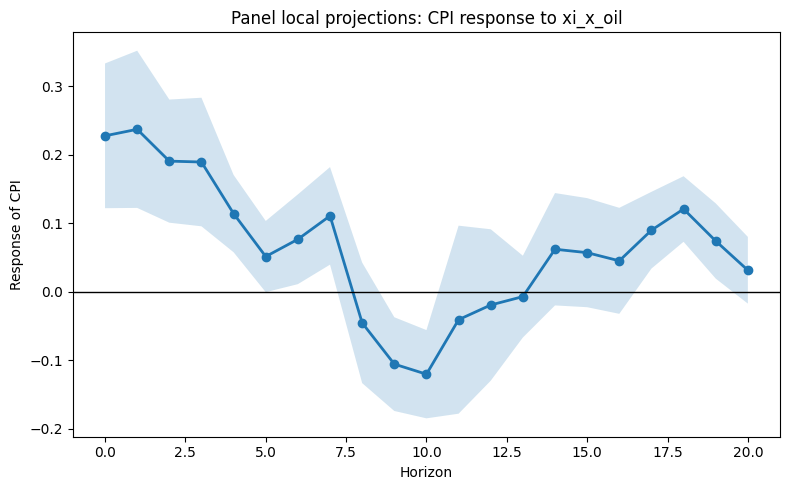

In [62]:
fig, ax = plt.subplots(figsize=(8, 5))
lp.plot_irf(irf_df, ax=ax)
plt.tight_layout()
plt.show()


In [63]:
horizon_to_inspect = 0
print(models[horizon_to_inspect].summary())


                             OLS Regression Results                             
Dep. Variable:     cpi_pct_change_lead0   R-squared:                       0.176
Model:                              OLS   Adj. R-squared:                  0.167
Method:                   Least Squares   F-statistic:                     10.93
Date:                  Fri, 27 Mar 2026   Prob (F-statistic):           4.55e-06
Time:                          19:09:28   Log-Likelihood:                 11886.
No. Observations:                  7252   AIC:                        -2.361e+04
Df Residuals:                      7170   BIC:                        -2.304e+04
Df Model:                            81                                         
Covariance Type:                cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const         

c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 81, but rank is 3
  warnings.warn('covariance of constraints does not have full '
